# Experiments

The objective of this notebook is experiment with diferrent models from `scikit-learn` and `XGBoost` and reach a conclusion of each model is better for the classify task.

## Content

- [Dummy Classifier](#Dummy-Classifier)
- [Logistic Regression](#Logistic-Regression)
- [Random Forest](#Random-Forest)
- [XGBoost](#XGBoost)
- [Conclusion](#Conclusion)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_rel
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier

In [2]:
import sys

from pyprojroot import here

sys.path.append(str(here()))

from src.exist.config import output_data_dir

In [3]:
df = pd.read_parquet(output_data_dir)

In [4]:
X = df.drop("class", axis=1).values
y = df["class"].values

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Dummy Classifier

In [7]:
dummy_mf = DummyClassifier(strategy="most_frequent", random_state=42)
scores_mf = cross_val_score(dummy_mf, X_train, y_train, cv=cv, scoring="f1_macro")

dummy_str = DummyClassifier(strategy="stratified", random_state=42)
scores_str = cross_val_score(dummy_str, X_train, y_train, cv=cv, scoring="f1_macro")

print(f"Dummy (most_frequent): {scores_mf.mean():.3f} ± {scores_mf.std():.3f}")
print(f"Dummy (stratified):    {scores_str.mean():.3f} ± {scores_str.std():.3f}")

Dummy (most_frequent): 0.249 ± 0.000
Dummy (stratified):    0.333 ± 0.003


## Logistic Regression

In [8]:
pipe_lr = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)

In [9]:
baseline = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring="f1_macro")

print(f"Baseline: {baseline.mean():.3f} +- {baseline.std():.3f}")

Baseline: 0.948 +- 0.003


In [10]:
param_grid_lr = {"model__C": [0.1, 1, 10, 100, 200]}

search_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=cv, scoring="f1_macro", n_jobs=-1)
search_lr.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informatio

In [11]:
results_lr = search_lr.cv_results_

std_lr = results_lr["std_test_score"][search_lr.best_index_]

print(f"LR: {search_lr.best_score_:.3f} ± {std_lr:.3f}")

LR: 0.954 ± 0.002


In [12]:
best_pipe_lr = search_lr.best_estimator_

y_pred_lr = best_pipe_lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

      GALAXY       0.96      0.98      0.97     11889
         QSO       0.95      0.89      0.92      3792
        STAR       0.97      1.00      0.99      4319

    accuracy                           0.96     20000
   macro avg       0.96      0.95      0.96     20000
weighted avg       0.96      0.96      0.96     20000



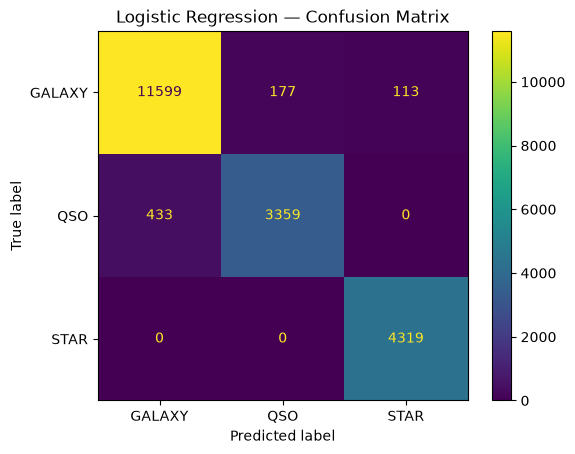

In [13]:
ConfusionMatrixDisplay.from_estimator(best_pipe_lr, X_test, y_test)
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

## Random Forest

In [14]:
pipe_rf = Pipeline([("model", RandomForestClassifier(random_state=42, n_jobs=1))])

In [15]:
param_grid_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 15, 20, None],
    "model__min_samples_leaf": [1, 3, 5],
    "model__max_features": ["sqrt", "log2"],
}

search_rf = RandomizedSearchCV(
    pipe_rf,
    param_distributions=param_grid_rf,
    n_iter=15,
    cv=cv,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1,
)

search_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [10, 15, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 3, ...], 'model__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` 

In [16]:
results_rf = search_rf.cv_results_

std_rf = results_rf["std_test_score"][search_rf.best_index_]

print(f"RF: {search_rf.best_score_:.3f} ± {std_rf:.3f}")

RF: 0.976 ± 0.001


In [17]:
best_pipe_rf = search_rf.best_estimator_

y_pred_rf = best_pipe_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       0.99      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



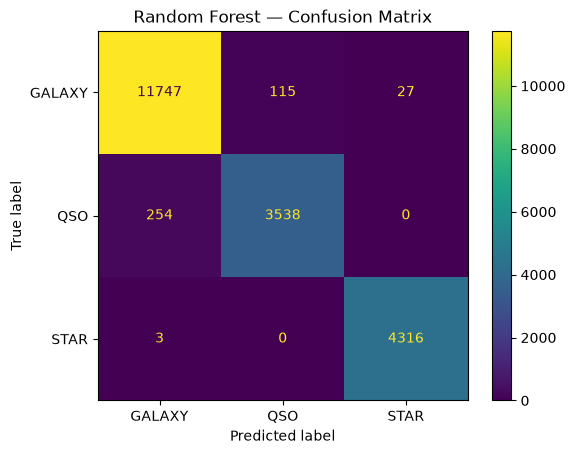

In [18]:
ConfusionMatrixDisplay.from_estimator(best_pipe_rf, X_test, y_test)
plt.title("Random Forest — Confusion Matrix")
plt.show()

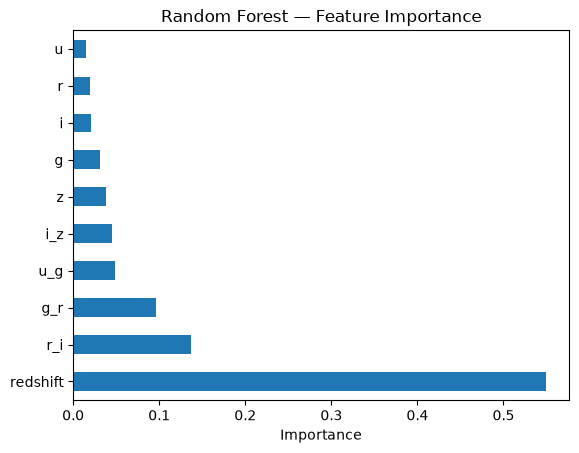

In [19]:
importances = search_rf.best_estimator_["model"].feature_importances_

dfX = df.drop("class", axis=1)

importance = pd.Series(importances, index=dfX.columns).sort_values(ascending=False)

importance.plot(kind="barh")
plt.xlabel("Importance")
plt.title("Random Forest — Feature Importance")
plt.show()

## XGBoost

In [20]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [21]:
pipe_xgb = Pipeline(
    [
        (
            "model",
            XGBClassifier(
                random_state=42, eval_metric="mlogloss", tree_method="hist", n_jobs=1
            ),
        )
    ]
)

In [22]:
param_grid_xgb = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

search_xgb = RandomizedSearchCV(
    pipe_xgb,
    param_distributions=param_grid_xgb,
    n_iter=15,
    cv=cv,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1,
)

search_xgb.fit(X_train, y_train_encoded)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``pred

In [23]:
results_xgb = search_xgb.cv_results_

std_xgb = results_xgb["std_test_score"][search_xgb.best_index_]

print(f"XGB: {search_xgb.best_score_:.3f} ± {std_xgb:.3f}")

XGB: 0.974 ± 0.001


In [24]:
best_pipe_xgb = search_xgb.best_estimator_

y_pred_xgb = best_pipe_xgb.predict(X_test)

print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_))

              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.96      0.93      0.94      3792
        STAR       0.99      1.00      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



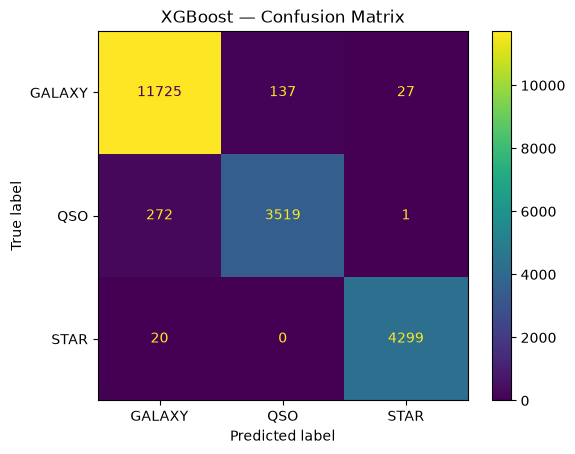

In [25]:
ConfusionMatrixDisplay.from_estimator(
    best_pipe_xgb, X_test, y_test_encoded, display_labels=le.classes_
)

plt.title("XGBoost — Confusion Matrix")
plt.show()

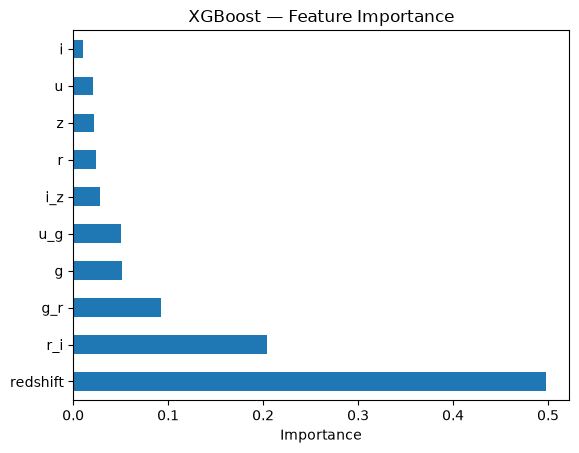

In [26]:
importances_xgb = search_xgb.best_estimator_["model"].feature_importances_

importance = pd.Series(importances_xgb, index=dfX.columns).sort_values(ascending=False)

importance.plot(kind="barh")
plt.xlabel("Importance")
plt.title("XGBoost — Feature Importance")
plt.show()

## Model comparision - Random Forest x XGBoost

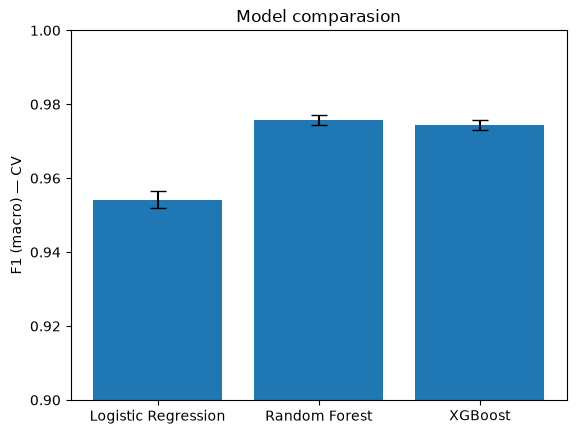

In [27]:
models = ["Logistic Regression", "Random Forest", "XGBoost"]
scores = [search_lr.best_score_, search_rf.best_score_, search_xgb.best_score_]
stds = [std_lr, std_rf, std_xgb]

plt.bar(models, scores, yerr=stds, capsize=6)
plt.ylabel("F1 (macro) — CV")
plt.ylim(0.9, 1.0)
plt.title("Model comparasion")
plt.show()

In [28]:
rf_fold_scores = [
    search_rf.cv_results_[f"split{i}_test_score"][search_rf.best_index_]
    for i in range(5)
]
xgb_fold_scores = [
    search_xgb.cv_results_[f"split{i}_test_score"][search_xgb.best_index_]
    for i in range(5)
]

t_stat, p_value = ttest_rel(rf_fold_scores, xgb_fold_scores)
print(f"RF folds:  {[round(s, 4).item() for s in rf_fold_scores]}")
print(f"XGB folds: {[round(s, 4).item() for s in xgb_fold_scores]}")
print(f"t = {t_stat:.3f}, p = {p_value:.3f}")

RF folds:  [0.9754, 0.9772, 0.9758, 0.9735, 0.9767]
XGB folds: [0.9741, 0.9761, 0.9726, 0.9732, 0.9755]
t = 3.034, p = 0.039


## Conclusion

### Final model choice

| Model                 | F1 macro (CV) | f1 macro (Test) |
|-----------------------|---------------|-----------------|
| Dummy (most_frequent) | 0.249 ± 0.000 | -               | 
| Dummy (stratified)    | 0.333 ± 0.003 | -               |
| Logistic Regression   | 0.954 ± 0.002 | 0.96            | 
| Random Forest         | 0.973 ± 0.001 | 0.98            |
| XGBoost               | 0.973 ± 0.001 | 0.98            |

**Decision:** Random Forest.

**Justification:** Logistic Regression was left behind with a diferrence of `0.02` between the other models, this indicates that the border between classes wasn't well captured by the linear model. Random Forest and XGBoost drew statistically (`t = -2.056`, `p = 0.109`) in the cross-validation, therefore the tiebreaker was the behavior of those models in the Confusion Matrix: Random Forest made fewer mistakes. another reason is that the Random Forest is a simpler model, thus easier to maintain (without LabelEncoder or external dependency) in the production stage.